# Import and inputs

In [14]:
# Imports and setup
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

import pandas as pd

repo_root = str(Path("..").resolve())
case_study_root = str(Path(".").resolve())
for path in (repo_root, case_study_root):
    if path not in sys.path:
        sys.path.insert(0, path)

# Notebook-specific imports
import re

from SynFlow.Explorer import (
    build_feat_df,
    compute_saturating_support_from_sfiller_df,
    feat_explorer,
    spaths_json_to_slotfiller_df,
)
from SynFlow.Explorer.sfiller_df import get_all_slots
from SynFlow.SCD import (
    compute_consecutive_dist_df,
    compute_period_period_dist,
    compute_weighted_consecutive_dist_df,
    count_keyword_tokens_by_period,
    freq_all_slots_by_period,
    multiply_consecutive_dist_saturating_support,
    permutation_test_consecutive_dist,
    plot_all_dists_by_period,
    plot_freq_top_union_slots_by_period,
    plot_period_period_dist,
    plot_permutation_test_consecutive_dist,
    summarize_fdr_correction,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# Specify required input


# Regex corpus_pattern to extract relevant information from SynFlow parsed files
corpus_pattern = re.compile(
    r"([^\t]+)\t"      # word form
    r"([^\t]+)\t"      # lemma
    r"([^\t]+)\t"      # POS (UPOS or XPOS)
    r"([^\t]+)\t"      # ID
    r"([^\t]+)\t"      # HEAD
    r"([^\t]+)\t"      # DEPREL
    r"([^\t]+)"        # FEATS
)

# Specify target lemma and part of speech
target_lemma = "viral"
target_pos = "ADJ"

# Specify corpus and output folders
period = "1995-2025"
corpus_folder = f"/home/volt/bach/Corpora/deu_news_1995-2025_sentences_parsed"
output_folder = Path(".").resolve()

# The path to the slot count JSON file
feat_json_path = f"output/{target_lemma}_{target_pos}_{period}/Explorer/{target_lemma}_{target_pos}_feats.json"


In [16]:
# Dont change below this line
output_folder_lemma = output_folder / "output" / f"{target_lemma}_{target_pos}_{period}"
output_explorer = f"{output_folder_lemma}/Explorer"
output_embedding = f"{output_folder_lemma}/Embedding"
input_SCD = output_folder / "input" / f"{target_lemma}_{target_pos}_{period}" / "SCD"
output_SCD = output_folder / "output" /f"{target_lemma}_{target_pos}_{period}" / "SCD"

os.makedirs(output_explorer, exist_ok=True)
os.makedirs(output_embedding, exist_ok=True)
os.makedirs(input_SCD, exist_ok=True)
os.makedirs(output_SCD, exist_ok=True)

# Explore the distribution of different types of features from the corpus

[1995-2000] Collected 59 FEATS type occurrences, 5 distinct types.


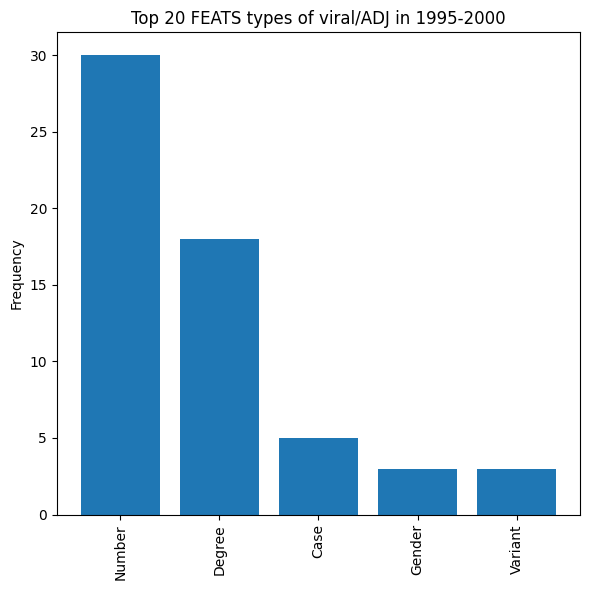

[2001-2005] Collected 38 FEATS type occurrences, 5 distinct types.


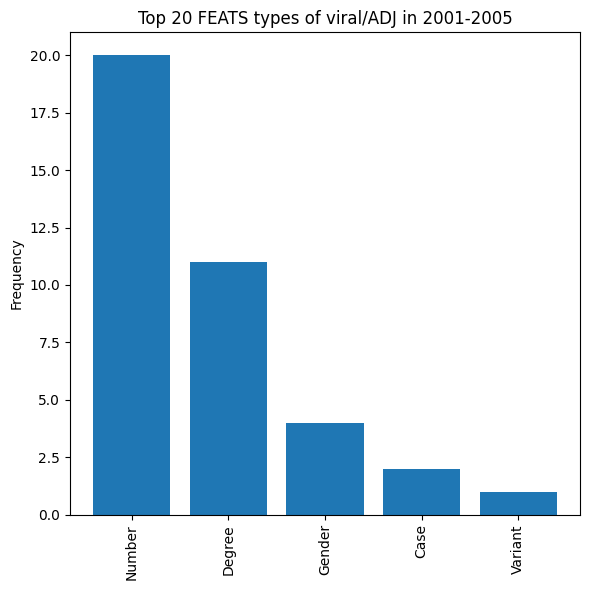

[2006-2010] Collected 152 FEATS type occurrences, 5 distinct types.


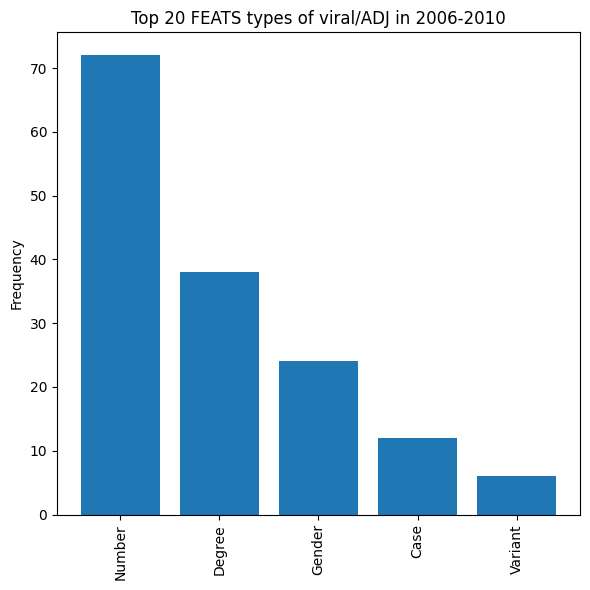

[2011-2015] Collected 243 FEATS type occurrences, 5 distinct types.


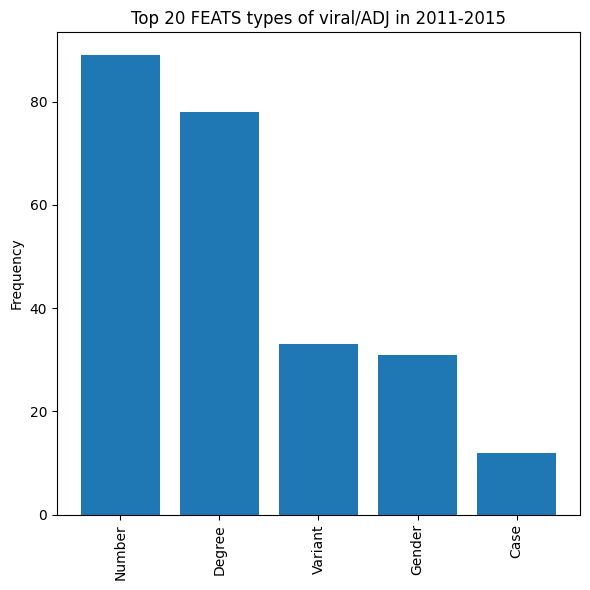

[2016-2020] Collected 413 FEATS type occurrences, 5 distinct types.


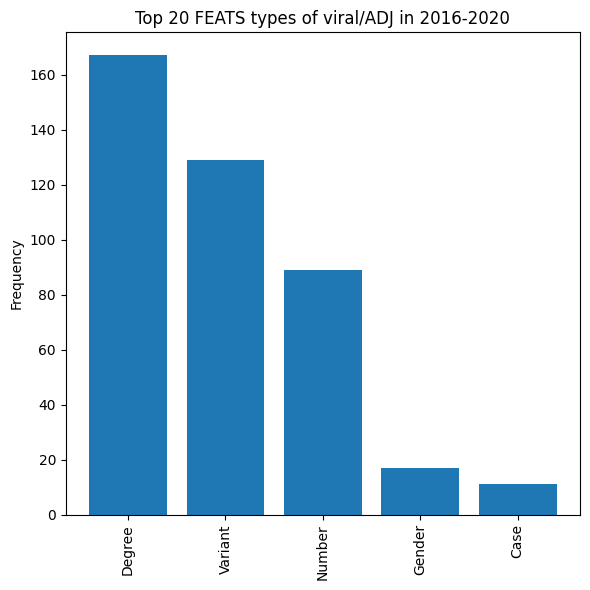

[2021-2025] Collected 940 FEATS type occurrences, 5 distinct types.


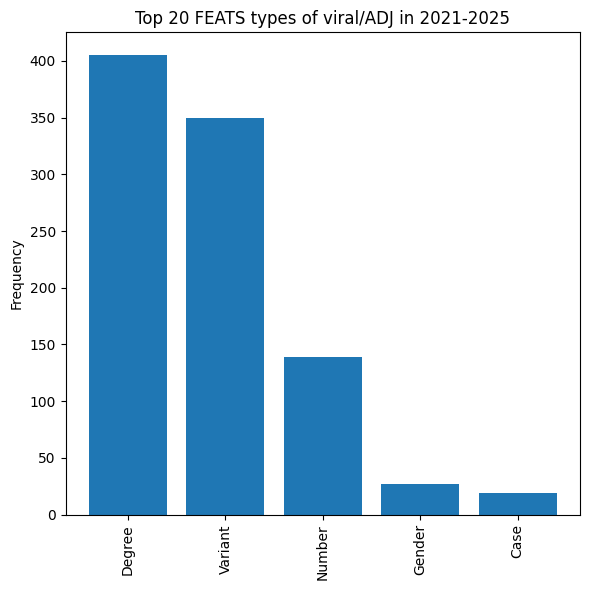

Saved FEATS type frequencies to: /home/volt/bach/SynFlow/notebooks/output/viral_ADJ_1995-2025/Explorer/viral_ADJ_feats.json


In [17]:
feat = feat_explorer(
    corpus_folder=corpus_folder,
    target_lemma=target_lemma,
    target_pos=target_pos,
    output_folder=output_explorer,
    top_n=20,
)

In [18]:
# Token counts for normalisation
token_counts = count_keyword_tokens_by_period(corpus_folder, target_lemma, target_pos,
                                              max_workers=64)
print(token_counts)


{'1995-2000': 70, '2001-2005': 62, '2006-2010': 155, '2011-2015': 193, '2016-2020': 311, '2021-2025': 627}


In [19]:
plot_freq_top_union_slots_by_period(
    json_path=feat_json_path,
    top_n=10,
    normalized=True,
    relative=False,
    token_counts=token_counts,
)


In [20]:
feat_raw_freq_df = freq_all_slots_by_period(json_path=feat_json_path).T
feat_raw_freq_df.head(30)

,1995-2000,2001-2005,2006-2010,2011-2015,2016-2020,2021-2025
Number,30.0,20.0,72.0,89.0,89.0,139.0
Degree,18.0,11.0,38.0,78.0,167.0,405.0
Case,5.0,2.0,12.0,12.0,11.0,19.0
Gender,3.0,4.0,24.0,31.0,17.0,27.0
Variant,3.0,1.0,6.0,33.0,129.0,350.0


# Build feat_type df of all features

In [21]:
feat_type_df = spaths_json_to_slotfiller_df(json_path=feat_json_path,
                                       exclude=[""]
                                       )

print(feat_type_df.head(10))
feat_type_df.to_csv(f"{input_SCD}/{target_lemma}_{target_pos}_feat_type_df.csv", index=False)

             id  subfolder          target         type
0   1995-2000_1  1995-2000  [(viral_ADJ,)]  [(Number,)]
1   1995-2000_2  1995-2000  [(viral_ADJ,)]  [(Number,)]
2   1995-2000_3  1995-2000  [(viral_ADJ,)]  [(Number,)]
3   1995-2000_4  1995-2000  [(viral_ADJ,)]  [(Number,)]
4   1995-2000_5  1995-2000  [(viral_ADJ,)]  [(Number,)]
5   1995-2000_6  1995-2000  [(viral_ADJ,)]  [(Number,)]
6   1995-2000_7  1995-2000  [(viral_ADJ,)]  [(Number,)]
7   1995-2000_8  1995-2000  [(viral_ADJ,)]  [(Number,)]
8   1995-2000_9  1995-2000  [(viral_ADJ,)]  [(Number,)]
9  1995-2000_10  1995-2000  [(viral_ADJ,)]  [(Number,)]


# Build feat_df

In [41]:
# Get all slots in the corect format
all_feats = get_all_slots(feat_raw_freq_df)
print(all_feats)


[Number][Degree][Case][Gender][Variant]


In [42]:
feat_df, dropped_list = build_feat_df(
    corpus_folder=corpus_folder,
    target_lemma=target_lemma,
    target_pos=target_pos,
    template=all_feats, # Feature template, e.g. [Number][Tense][VerbForm]
    pattern=corpus_pattern,
    )

In [43]:
feat_df

,subfolder,target,Number,Degree,Case,Gender,Variant
id,,,,,,,
viral/deu_news_1995_1M-sentences.txt/5615020,1995-2000,"[(viral/ADJ,)]","[(Plur,)]","[(Pos,)]",[],[],[]
viral/deu_news_1995_1M-sentences.txt/8050421,1995-2000,"[(viral/ADJ,)]","[(Plur,)]","[(Pos,)]",[],[],[]
viral/deu_news_1995_1M-sentences.txt/9954933,1995-2000,"[(viral/ADJ,)]",[],"[(Pos,)]",[],[],[]
viral/deu_news_1995_1M-sentences.txt/10697085,1995-2000,"[(viral/ADJ,)]","[(Plur,)]","[(Pos,)]",[],[],[]
viral/deu_news_1996_1M-sentences.txt/3064311,1995-2000,"[(viral/ADJ,)]","[(Sing,)]","[(Pos,)]","[(Dat,)]",[],[]
...,...,...,...,...,...,...,...
viral/deu_news_2025_1M-sentences.txt/18867898,2021-2025,"[(viral/ADJ,)]",[],"[(Pos,)]",[],[],"[(Short,)]"
viral/deu_news_2025_1M-sentences.txt/19016065,2021-2025,"[(viral/ADJ,)]","[(Sing,)]",[],[],[],[]
viral/deu_news_2025_1M-sentences.txt/19203687,2021-2025,"[(viral/ADJ,)]",[],"[(Pos,)]",[],[],"[(Short,)]"


In [44]:
# Save to csv, remember to add the filler format to the name
all_feat_csv_path = f"{input_SCD}/{target_lemma}_{target_pos}_feat_df_all.csv"
feat_df.to_csv(all_feat_csv_path)

# Calculate (weighted) distance of all feature types/features distribution

In [45]:
# feat_df_path = f"{input_SCD}/{target_lemma}_{target_pos}_feat_type_df.csv"
feat_df_path = f"{input_SCD}/{target_lemma}_{target_pos}_feat_df_all.csv"
feat_df = pd.read_csv(feat_df_path)


In [46]:
feat_df

,id,subfolder,target,Number,Degree,Case,Gender,Variant
0,viral/deu_news_1995_1M-sentences.txt/5615020,1995-2000,"[('viral/ADJ',)]","[('Plur',)]","[('Pos',)]",[],[],[]
1,viral/deu_news_1995_1M-sentences.txt/8050421,1995-2000,"[('viral/ADJ',)]","[('Plur',)]","[('Pos',)]",[],[],[]
2,viral/deu_news_1995_1M-sentences.txt/9954933,1995-2000,"[('viral/ADJ',)]",[],"[('Pos',)]",[],[],[]
3,viral/deu_news_1995_1M-sentences.txt/10697085,1995-2000,"[('viral/ADJ',)]","[('Plur',)]","[('Pos',)]",[],[],[]
4,viral/deu_news_1996_1M-sentences.txt/3064311,1995-2000,"[('viral/ADJ',)]","[('Sing',)]","[('Pos',)]","[('Dat',)]",[],[]
...,...,...,...,...,...,...,...,...
962,viral/deu_news_2025_1M-sentences.txt/18867898,2021-2025,"[('viral/ADJ',)]",[],"[('Pos',)]",[],[],"[('Short',)]"
963,viral/deu_news_2025_1M-sentences.txt/19016065,2021-2025,"[('viral/ADJ',)]","[('Sing',)]",[],[],[],[]
964,viral/deu_news_2025_1M-sentences.txt/19203687,2021-2025,"[('viral/ADJ',)]",[],"[('Pos',)]",[],[],"[('Short',)]"
965,viral/deu_news_2025_1M-sentences.txt/19395831,2021-2025,"[('viral/ADJ',)]",[],"[('Pos',)]",[],[],"[('Short',)]"


## Compute raw distance

In [47]:

consecutive_dist = compute_consecutive_dist_df(
    sfiller_df=feat_df,
    period_col="subfolder",
    min_freq=1,
    mode="data_only",  # "all" or "data_only" if you want to skip empty periods
    measure="tvd"
)
consecutive_dist


,slot,period_1,period_2,measure,dist
0,Number,1995-2000,2001-2005,tvd,0.366667
1,Number,2001-2005,2006-2010,tvd,0.119444
2,Number,2006-2010,2011-2015,tvd,0.038546
3,Number,2011-2015,2016-2020,tvd,0.000000
4,Number,2016-2020,2021-2025,tvd,0.064425
5,Degree,1995-2000,2001-2005,tvd,0.000000
6,Degree,2001-2005,2006-2010,tvd,0.000000
7,Degree,2006-2010,2011-2015,tvd,0.000000
8,Degree,2011-2015,2016-2020,tvd,0.000000
9,Degree,2016-2020,2021-2025,tvd,0.000000


## Compute support for the distance

In [48]:

saturating_support = compute_saturating_support_from_sfiller_df(
    sfiller_df=feat_df,
    period_col="subfolder",
    min_freq=1,
    mode="data_only", # "all" or "data_only" if you want to skip empty periods
    k=10,
)

saturating_support


,slot,period_1,period_2,support_count,support_weight
0,Number,1995-2000,2001-2005,20.0,1.0
1,Number,2001-2005,2006-2010,20.0,1.0
2,Number,2006-2010,2011-2015,72.0,1.0
3,Number,2011-2015,2016-2020,89.0,1.0
4,Number,2016-2020,2021-2025,89.0,1.0
5,Degree,1995-2000,2001-2005,11.0,1.0
6,Degree,2001-2005,2006-2010,11.0,1.0
7,Degree,2006-2010,2011-2015,38.0,1.0
8,Degree,2011-2015,2016-2020,78.0,1.0
9,Degree,2016-2020,2021-2025,167.0,1.0


## Compute weighted distance (raw distance x support)

In [49]:
weighted_consecutive_dist = multiply_consecutive_dist_saturating_support(
    consecutive_dist_df=consecutive_dist,
    saturating_support=saturating_support,
)
weighted_consecutive_dist


,slot,period_1,period_2,measure,dist,support_count,support_weight,weighted_dist
0,Number,1995-2000,2001-2005,tvd,0.366667,20.0,1.0,0.366667
1,Number,2001-2005,2006-2010,tvd,0.119444,20.0,1.0,0.119444
2,Number,2006-2010,2011-2015,tvd,0.038546,72.0,1.0,0.038546
3,Number,2011-2015,2016-2020,tvd,0.000000,89.0,1.0,0.000000
4,Number,2016-2020,2021-2025,tvd,0.064425,89.0,1.0,0.064425
5,Degree,1995-2000,2001-2005,tvd,0.000000,11.0,1.0,0.000000
6,Degree,2001-2005,2006-2010,tvd,0.000000,11.0,1.0,0.000000
7,Degree,2006-2010,2011-2015,tvd,0.000000,38.0,1.0,0.000000
8,Degree,2011-2015,2016-2020,tvd,0.000000,78.0,1.0,0.000000
9,Degree,2016-2020,2021-2025,tvd,0.000000,167.0,1.0,0.000000


In [50]:
# Combined function

weighted_consecutive_dist = compute_weighted_consecutive_dist_df(
    sfiller_df=feat_df,
    period_col="subfolder",
    min_freq=1,
    mode="data_only", # "all" or "data_only" if you want to skip empty periods
    k=10,
    measure="tvd"
)
weighted_consecutive_dist


,slot,period_1,period_2,measure,dist,support_count,support_weight,weighted_dist
0,Number,1995-2000,2001-2005,tvd,0.366667,20.0,1.0,0.366667
1,Number,2001-2005,2006-2010,tvd,0.119444,20.0,1.0,0.119444
2,Number,2006-2010,2011-2015,tvd,0.038546,72.0,1.0,0.038546
3,Number,2011-2015,2016-2020,tvd,0.000000,89.0,1.0,0.000000
4,Number,2016-2020,2021-2025,tvd,0.064425,89.0,1.0,0.064425
5,Degree,1995-2000,2001-2005,tvd,0.000000,11.0,1.0,0.000000
6,Degree,2001-2005,2006-2010,tvd,0.000000,11.0,1.0,0.000000
7,Degree,2006-2010,2011-2015,tvd,0.000000,38.0,1.0,0.000000
8,Degree,2011-2015,2016-2020,tvd,0.000000,78.0,1.0,0.000000
9,Degree,2016-2020,2021-2025,tvd,0.000000,167.0,1.0,0.000000


## Permutation test

In [51]:
perm_result_df = permutation_test_consecutive_dist(
    sfiller_df=feat_df,
    period_col="subfolder",
    n_permutations=1000,
    min_freq=1,
    measure="tvd",
    k=1,
    weighting=True,
    seed=42,
    num_processes=100,
    chunk_size=10,
)

Permutation testing for pair 1/5: 1995-2000 -> 2001-2005
Permutation testing for pair 2/5: 2001-2005 -> 2006-2010
Permutation testing for pair 3/5: 2006-2010 -> 2011-2015
Permutation testing for pair 4/5: 2011-2015 -> 2016-2020
Permutation testing for pair 5/5: 2016-2020 -> 2021-2025


In [52]:
# perm_result_df_path = f"{output_SCD}/{target_lemma}_{target_pos}_feat_type_perm_result_df.csv"
perm_result_df_path = f"{output_SCD}/{target_lemma}_{target_pos}_feat_perm_result_df.csv"

In [53]:
print(perm_result_df)
perm_result_df.to_csv(perm_result_df_path)

       slot   period_1   period_2 measure     statistic  weighting  \
0    Number  1995-2000  2001-2005     tvd  weighted_tvd       True   
1    Degree  1995-2000  2001-2005     tvd  weighted_tvd       True   
2      Case  1995-2000  2001-2005     tvd  weighted_tvd       True   
3    Gender  1995-2000  2001-2005     tvd  weighted_tvd       True   
4   Variant  1995-2000  2001-2005     tvd  weighted_tvd       True   
5    Number  2001-2005  2006-2010     tvd  weighted_tvd       True   
6    Degree  2001-2005  2006-2010     tvd  weighted_tvd       True   
7      Case  2001-2005  2006-2010     tvd  weighted_tvd       True   
8    Gender  2001-2005  2006-2010     tvd  weighted_tvd       True   
9   Variant  2001-2005  2006-2010     tvd  weighted_tvd       True   
10   Number  2006-2010  2011-2015     tvd  weighted_tvd       True   
11   Degree  2006-2010  2011-2015     tvd  weighted_tvd       True   
12     Case  2006-2010  2011-2015     tvd  weighted_tvd       True   
13   Gender  2006-20

In [54]:
perm_result_df=pd.read_csv(perm_result_df_path)

### Plot permutation tests

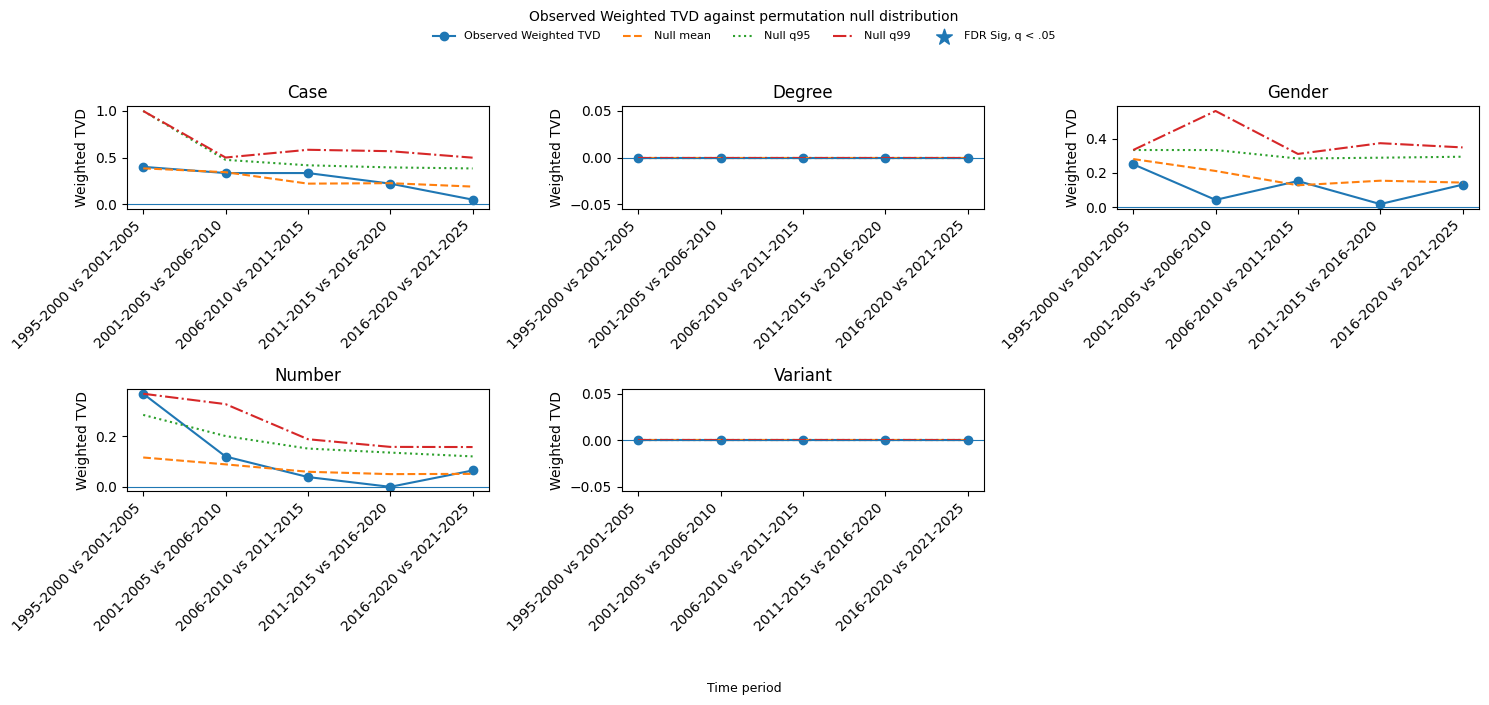

In [55]:
plot_permutation_test_consecutive_dist(perm_result_df)

In [56]:
perm_fdr_summary, corrected_feat_period_df = summarize_fdr_correction(perm_result_df)

perm_fdr_summary
# perm_fdr_summary.to_csv(rf"{output_SCD}/{target_lemma}_{target_pos}_feat_type_perm_fdr_summary.csv", index=False)
perm_fdr_summary.to_csv(rf"{output_SCD}/{target_lemma}_{target_pos}_feat_perm_fdr_summary.csv", index=False)
# corrected_feat_period_df

In [57]:
perm_fdr_summary

,slot,total_period_tests,valid_period_tests,invalid_period_tests,raw_p_significant,fdr_significant,corrected_by_fdr,raw_significant_percent,fdr_significant_percent,fdr_corrected_percent_of_raw_sig
0,Case,5,5,0,0,0,0,0.0,0.0,0.0
1,Degree,5,5,0,0,0,0,0.0,0.0,0.0
2,Gender,5,5,0,0,0,0,0.0,0.0,0.0
3,Number,5,5,0,1,0,1,20.0,0.0,100.0
4,Variant,5,5,0,0,0,0,0.0,0.0,0.0


## Compute period x period distance matrix

In [62]:

period_period_dist_df = compute_period_period_dist(
    sfiller_df=feat_df,
    period_col="subfolder",
    slot_col='Variant', # Required when the data contains multiple slot/feature types, otherwise set to None.
    min_freq=1,
    measure="tvd",
    mode="data_only",
    weighting=False,
    k=1,
)

fig = plot_period_period_dist(period_period_dist_df)
fig.show()

Computing period-period distribution distance with measure: tvd


# Plot distance time-series

In [60]:
# Plot all feats on one big plot

# slots_to_plot = ['Number', 'VerbForm']  # Specify the feat you want to plot
# plot_all_dists_by_period(perm_result_df, layout='combined', slots=slots_to_plot)

# If not specify, plot everything
plot_all_dists_by_period(perm_result_df, layout="combined", col_to_plot="observed_statistic")